In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [3]:
import sys
sys.path.append('..')

from micrograd.engine import Value
from micrograd.neuralnet import MLP

In [4]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [5]:
X, y = mnist.data, mnist.target
X.shape, y.shape, type(X[0]), type(y[0])

((70000, 784), (70000,), numpy.ndarray, str)

In [6]:
y = y.astype(int)

In [7]:
#Take a stratified random sample of 100 digits from the larger dataset
X_data, _, y_data, _ = train_test_split(X, y, train_size=100, stratify=y, random_state=42)
X_data.shape, y_data.shape

((100, 784), (100,))

In [8]:
#Normalizing input vectors
X_data /= 255.0

Target value: 1


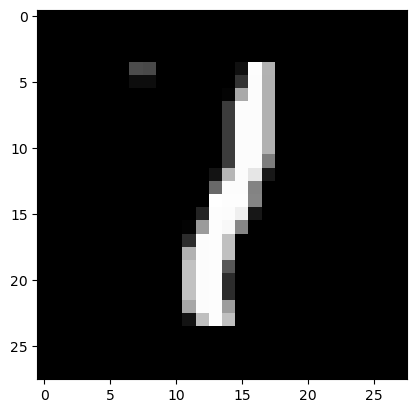

In [9]:
plt.imshow(X_data[0].reshape(28, 28), cmap='gray');
print(f'Target value: {y_data[0]}')

In [10]:
random.seed(42)
digit_classifier_mlp = MLP(784, [16, 16, 10])

In [11]:
def argmax(y_pred):
    return y_pred.index(max(y_pred))

In [12]:
def accuracy(y_preds, y_target):
    return sum(argmax(pred) == target for pred, target in zip(y_preds, y_target))/len(y_target)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, train_size=0.8, random_state=42)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 784), (20, 784), (80,), (20,))

In [15]:
def _softmax_cross_entropy(logits, target):
    # logits: list of Value objects from the MLP, length C
    # target: integer class label
    max_z = max(logit.data for logit in logits)
    # log-sum-exp, stable
    shifted = [logit - max_z for logit in logits]  # requires Value - scalar support
    exp_sum = sum((s.exp() for s in shifted), Value(0.0))
    log_sum_exp = exp_sum.log()
    return -logits[target] + log_sum_exp + max_z

In [16]:
def softmax_cross_entropy(y_logits, y_target):
    return sum(_softmax_cross_entropy(logits, target) for logits, target in zip(y_logits, y_target))/len(y_target)

In [17]:
y_logits = [digit_classifier_mlp(digit) for digit in X_train]
loss = softmax_cross_entropy(y_logits,y_train)
acc = accuracy(y_logits, y_train)
print(f'Accuracy: {acc}   |   Loss: {loss.data}')
y_logits[0]

Accuracy: 0.1125   |   Loss: 29.40559906244676


[Value(data=11.135630773126934),
 Value(data=-17.37701673124939),
 Value(data=5.372383452426684),
 Value(data=5.056125635448899),
 Value(data=22.35005790691376),
 Value(data=-15.206453086511111),
 Value(data=1.5583339987928804),
 Value(data=2.6906985261931347),
 Value(data=-1.4250582740407636),
 Value(data=2.4506173163276217)]

In [18]:
#Training loop

EPOCHS = 10
for i in range(EPOCHS):
    y_logits = [digit_classifier_mlp(digit) for digit in X_train]
    loss = softmax_cross_entropy(y_logits,y_train)

    digit_classifier_mlp.zero_grad()
    loss.backward()

    digit_classifier_mlp.SGDoptimize(lr=0.02)
    print(f'Epoch: {i}   |   Loss: {loss.data:.4f}')
    

Epoch: 0   |   Loss: 29.4056
Epoch: 1   |   Loss: 15.2537
Epoch: 2   |   Loss: 12.6175
Epoch: 3   |   Loss: 11.1310
Epoch: 4   |   Loss: 10.0235
Epoch: 5   |   Loss: 9.0861
Epoch: 6   |   Loss: 8.2996
Epoch: 7   |   Loss: 7.6379
Epoch: 8   |   Loss: 7.0636
Epoch: 9   |   Loss: 6.5713


In [19]:
#Final train accuracy
y_logits = [digit_classifier_mlp(digit) for digit in X_train]
loss = softmax_cross_entropy(y_logits, y_train)
acc = accuracy(y_logits, y_train)
print(f'Accuracy: {acc}   |   Loss: {loss.data}')
y_logits[0], y_train[0]

Accuracy: 0.25   |   Loss: 6.12414583317789


([Value(data=3.1386502298269767),
  Value(data=-4.740841718992016),
  Value(data=0.7332753027740304),
  Value(data=-0.4630706361372226),
  Value(data=2.040200177116836),
  Value(data=-4.651690735417127),
  Value(data=-1.2074247099754043),
  Value(data=4.766846103405184),
  Value(data=-2.2309953826632647),
  Value(data=-2.5367983897183786)],
 8)

In [20]:
#Final test accuracy
y_logits = [digit_classifier_mlp(digit) for digit in X_test]
loss = softmax_cross_entropy(y_logits, y_test)
acc = accuracy(y_logits, y_test)
print(f'Accuracy: {acc}   |   Loss: {loss.data}')
y_logits[0], y_test[0]

Accuracy: 0.15   |   Loss: 7.313069634221501


([Value(data=-4.610233613991454),
  Value(data=-2.93181950547703),
  Value(data=2.780552128234576),
  Value(data=0.10480459058848779),
  Value(data=4.712838893981154),
  Value(data=0.02220101252544593),
  Value(data=4.422506217467299),
  Value(data=3.2880893935412985),
  Value(data=0.19635172501468734),
  Value(data=-2.4737434788863255)],
 3)

In [ ]:
"""
Currently, running the training loop 10 times already takes 20-30min which is why 
I haven't trained the network for longer to improve accuracy. This is most likely 
a combination of the inefficiencies of a pure python neural network and my computer
being near the end of its surprisingly long lifespan. This test was mainly to
verify whether or not the backpropagation successfully reduced the loss.
"""